In [2]:
import numpy as np  
import matplotlib.pyplot as plt

(35.0, 50.0)

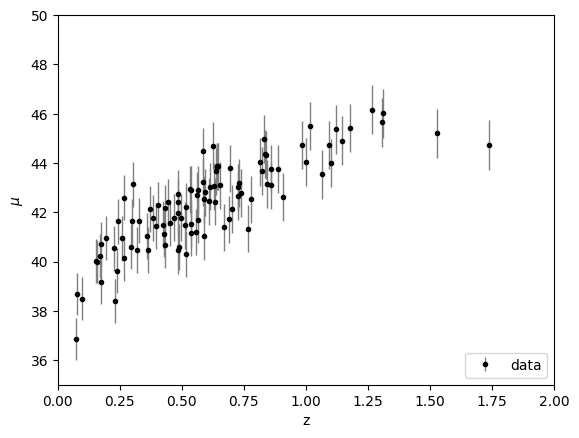

In [3]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)


### Let's perform GPR 

Alpha are the error**2

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern, DotProduct 


# Radial basis function kernel RBF 
kernel1 = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) #one possible kernel choice

z = np.linspace(0.01, 2, 1000)

gp = GaussianProcessRegressor(kernel=kernel1, alpha=dmu ** 2)

gp.fit(z_sample[:, None], mu_sample)    #fit the data

#return the mean, Standard deviation of predictive distribution
mu_fit, sigma = gp.predict(z[:, None], return_std=True)  


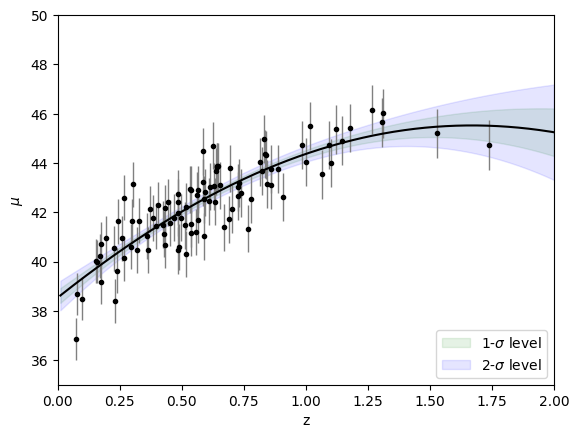

In [5]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

plt.plot(z, mu_fit, '-k')

plt.fill_between(z, mu_fit - sigma, mu_fit + sigma, alpha=0.1, color='g', label='1-$\sigma$ level')

plt.fill_between(z, mu_fit - 2* sigma, mu_fit + 2* sigma, alpha=0.1, color='b', label='2-$\sigma$ level')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

### Cross validation to choose the Kernel Hyperparameter

There is already an optimization of the kernel Hyperparameter (but we can switch off it)

In [6]:
from sklearn.model_selection import GridSearchCV, KFold


constant_values = np.linspace(0.1,10,10)
length_scales = np.linspace(0.1,10,10)

# fixed means that it does not apply any optimization 
# it uses the 10*10 combinations of the two parameters
kernel_list = [
    ConstantKernel(c, constant_value_bounds="fixed") * RBF(ls, length_scale_bounds="fixed")
    for c in constant_values
    for ls in length_scales
]

cv = KFold(n_splits=5, shuffle=True, random_state=42)
gpr = GaussianProcessRegressor(optimizer=None, alpha=0.9, normalize_y=True)

param_grid = {
    "kernel": kernel_list
}

search = GridSearchCV(
    estimator=gpr,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_squared_error", 
    n_jobs=-1,
    verbose=1
)

search.fit(z_sample[:, None], mu_sample)


Fitting 5 folds for each of 100 candidates, totalling 500 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=GaussianProcessRegressor(alpha=0.9, normalize_y=True,
                                                optimizer=None),
             n_jobs=-1,
             param_grid={'kernel': [0.316**2 * RBF(length_scale=0.1),
                                    0.316**2 * RBF(length_scale=1.2),
                                    0.316**2 * RBF(length_scale=2.3),
                                    0.316**2 * RBF(length_scale=3.4),
                                    0.316**2 * RBF(length_scale=4.5),
                                    0.316**2 * RBF(length_sc...
                                    1.1**2 * RBF(length_scale=10),
                                    1.52**2 * RBF(length_scale=0.1),
                                    1.52**2 * RBF(length_scale=1.2),
                                    1.52**2 * RBF(length_scale=2.3),
                                    1.52**2 * RBF(length_scale=3.4),
                                    1.52**2 * RBF(length_scale=4.5),
                                    1.52**2 * RBF(length_scale=5.6),
                                    1.52**2 * RBF(length_scale=6.7),
                                    1.52**2 * RBF(length_scale=7.8),
                                    1.52**2 * RBF(length_scale=8.9),
                                    1.52**2 * RBF(length_scale=10), ...]},
             scoring='neg_mean_squared_error', verbose=1)

Best kernel: 3.16**2 * RBF(length_scale=1.2)


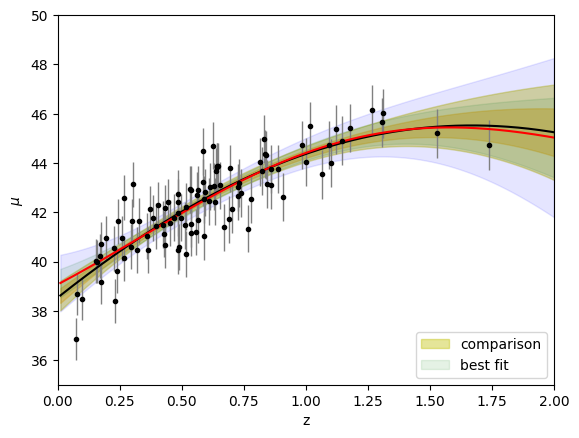

In [7]:
z = np.linspace(0.01, 2, 1000)
gp_best = search.best_estimator_
print("Best kernel:", gp_best.kernel_)

mu_fitb, sigmab = gp_best.predict(z[:, None], return_std=True)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

gp = GaussianProcessRegressor(kernel=kernel1, alpha=dmu ** 2)

gp.fit(z_sample[:, None], mu_sample)            
mu_fit, sigma = gp.predict(z[:, None], return_std=True)

plt.plot(z, mu_fit, '-k')

plt.fill_between(z, mu_fit - sigma, mu_fit + sigma, alpha=0.4, color='orange')

plt.fill_between(z, mu_fit - 2* sigma, mu_fit + 2* sigma, alpha=0.4, color='y', label='comparison')


plt.plot(z, mu_fitb, '-r')

plt.fill_between(z, mu_fitb - sigmab, mu_fitb + sigmab, alpha=0.1, color='g', label='best fit ')

plt.fill_between(z, mu_fitb - 2* sigmab, mu_fitb + 2* sigmab, alpha=0.1, color='b')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);


### Cloning data

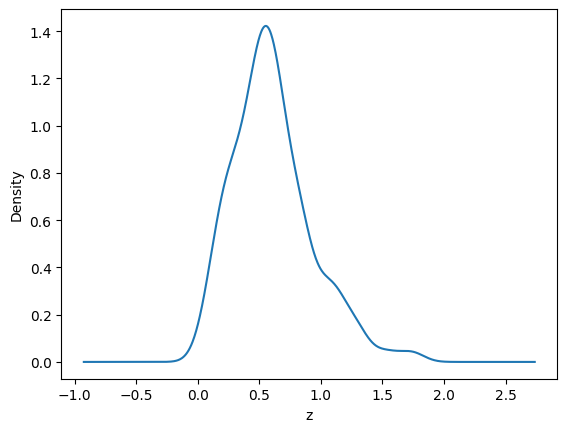

In [8]:
#VISUALIZE THE DISTRIBUTION OF DATA in z

from sklearn.neighbors import KernelDensity

z_vals = np.array(z_sample).reshape(-1, 1) 

kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(z_vals)

z_plot = np.linspace(z_vals.min() - 1, z_vals.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(z_plot)
dens = np.exp(log_dens)

plt.plot(z_plot[:, 0], dens)
plt.xlabel('z')
plt.ylabel('Density')
plt.show()

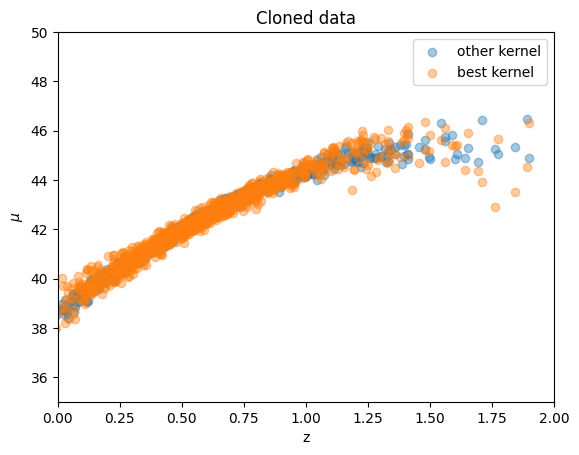

In [9]:
N = 1000
new_z_samples = kde.sample(N)   #N values that follow the pdf of z estimated by KDE

#now given the z (distributed as our sample)
mu_gpr=[]
mu_gprm=[]
for z in np.squeeze(new_z_samples):    
    mu_fit, sigma = gp_best.predict([[z]], return_std=True)
    mu_fitm, sigmam = gp.predict([[z]], return_std=True)

    #each data has also an error

    mu_gpr.append(np.random.normal(loc=mu_fit,scale=sigma))     
    mu_gprm.append(np.random.normal(loc=mu_fitm,scale=sigmam)) 

plt.scatter(new_z_samples,mu_gprm,alpha=0.4, label='other kernel')
plt.scatter(new_z_samples,mu_gpr,alpha=0.4, label='best kernel')


plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.legend()
plt.title("Cloned data");

### Part 3 : non linear fitting  following $\Lambda CDM$

Parametric fit

I'm bayesian

In [10]:
import emcee
import scipy.stats as scistats
import corner
import dynesty
from astropy.cosmology import LambdaCDM

In [11]:
def generativemodel(z, H0, Om=1):
    cosmo_tmp = LambdaCDM(H0=H0, Om0=Om, Ode0=1-Om) #assuming a flat universe 
    return cosmo_tmp.distmod(z).value 

### Likelihood definition
Parameter Hubble constant (H0) and Omega matter, $\Omega_{\Lambda}$ is $\Omega_{m}-1$ (flat universe)


In [12]:

def LogLikelihood(theta):
    Om,H0 = theta    
    if Om<0:
        return -np.inf
    else:
        mu_model = generativemodel(z_sample, H0, Om)
    
    return -0.5 * np.sum(((mu_sample - mu_model) / dmu) ** 2)

    "this version insted contains the normalization terms"
    #return np.sum(scistats.norm(loc=mu_model, scale=dmu).logpdf(mu_sample))    
     

### MCMC 

In [13]:
def Logprior(theta):
    Om,H0 = theta
    if 50 < H0 < 100 and 0.1 < Om < 1:      #UNIFORM PRIOR ON H0 AND OMEGA MATTER
        return 0.0
    return -np.inf

                   
def LogPosterior(theta):
    return LogLikelihood(theta) + Logprior(theta)

In [14]:
ndim = 2  # number of parameters in the model
nwalkers = 5  # number of MCMC walkers
nsteps = int(1e4)  # number of MCMC steps to take for each walker

#we assume Hubble constant=80 and Om = 0.5 as initial guess
starting_guesses = np.array([0.5,80]) + 1e-1* np.random.randn(nwalkers, ndim)       

print(starting_guesses.shape)

(5, 2)


In [15]:
#Where everything happens
sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)  
sampler.run_mcmc(starting_guesses, nsteps);

In [16]:
samples = sampler.get_chain()

# Let's see the autocorrelation length
tau = sampler.get_autocorr_time()
print(tau)

[58.99816931 55.14614364]


Let's have a look the tha chains (everything OK?)

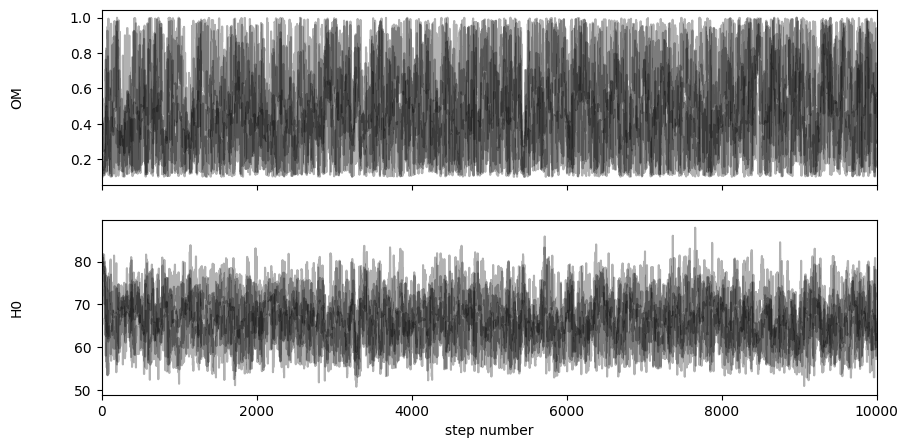

In [17]:
fig, axes = plt.subplots(2, figsize=(10, 5), sharex=True)
samples = sampler.get_chain()
labels = ["OM","H0"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

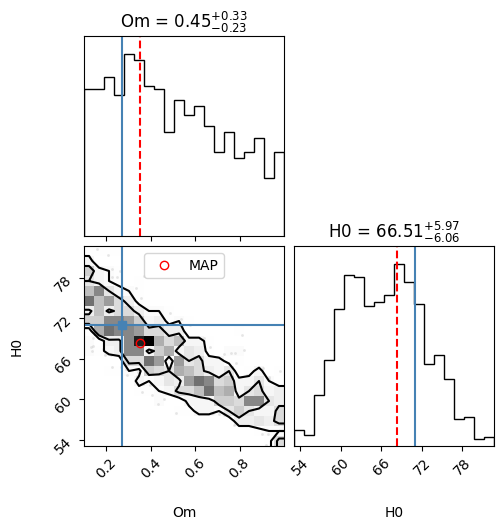

In [27]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)

log_prob = sampler.get_log_prob(discard=3*int(max(tau)), thin=int(max(tau)), flat=True) #the log probabilities evaluated at the MCMC samples
log_prob.shape #each value correspond to a set of parameters 
i_map = np.argmax(log_prob)                #index of the MAP

Om_map, H0_map = flat_samples[i_map]

fig = corner.corner(
    flat_samples, labels=["Om","H0"], levels=[0.68,0.95], show_titles=True, truths=[0.27,71])

axes = np.array(fig.axes).reshape((2, 2)) 


axes[1, 0].plot(Om_map, H0_map, "o", label="MAP",  markerfacecolor='none', markeredgecolor='red')
axes[1, 0].legend()


axes[0, 0].axvline(Om_map, color="r", linestyle="--")
axes[1, 1].axvline(H0_map, color="r", linestyle="--")

(35.0, 50.0)

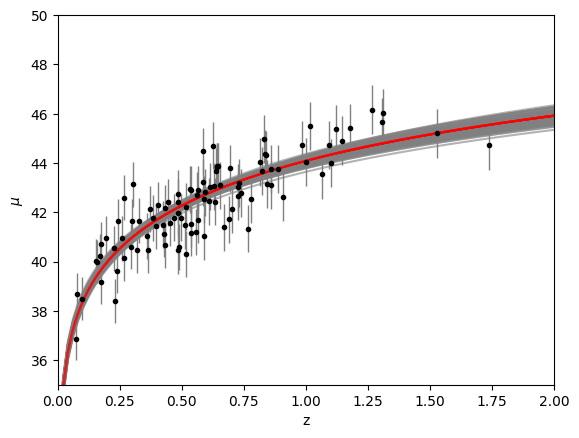

In [19]:
zlin = np.linspace(0,2,100)[1:]

samp100 = flat_samples[np.random.choice(len(flat_samples),size=100)] #100 random point in the posterior 

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

Om_map, H0_map = flat_samples[i_map]                #Max posterior parameter 

for i in range(len(samp100)):
    Om, H0 = samp100[i]
    y = generativemodel(zlin,H0, Om)
    w = generativemodel(zlin,H0_map, Om_map)
    plt.plot(zlin,y,alpha=0.6, c='gray')
    plt.plot(zlin,w,alpha=0.6, c='red')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)

In [20]:
print("MAP:", Om_map, H0_map)
Ho, Om = np.mean(flat_samples, axis=0)  #mean of the posterior samples
print("mean:", Ho, Om)
err_Ho, err_Om = np.std(flat_samples, axis=0)
print("error:", err_Ho, err_Om)

MAP: 0.3526144617097749 68.33613440721683
mean: 0.48827636437924515 66.53627815271406
error: 0.2467968682419398 5.764055763242064


### Savage Dickey density ratio 

Assuming $\Omega_{m}$=1

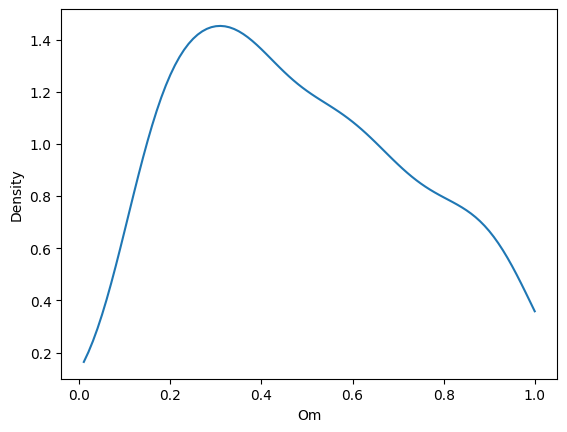

In [21]:
#already marginalized 

samplesOm= flat_samples[:,0]
Om=1

# 1 posterior probability of Om
kde = KernelDensity(kernel='gaussian', bandwidth=0.08).fit(samplesOm.reshape(-1, 1))

Om_plot = np.linspace(0.01, 1, 100).reshape(-1, 1)
log_dens = kde.score_samples(Om_plot)
dens = np.exp(log_dens)

plt.plot(Om_plot[:, 0], dens)
plt.xlabel('Om')
plt.ylabel('Density')
plt.show()

In [22]:
posterior_density = np.exp(kde.score_samples([[1]]))
print("Posterior probability of Om=1:", posterior_density)

Posterior probability of Om=1: [0.35860618]


In [23]:
# 2. Prior probability of Om=1

prior_density = 1 / (1 - 0.1)  # Uniform prior between 0.1 and 1

# 3.Bayes Factor
Bf = prior_density/posterior_density
print("Bayes factor of (Om, OLambda) vs Om only:", Bf)

Bayes factor of (Om, OLambda) vs Om only: [3.09841597]
